# KS 5 — Reading results honestly

Estimated time: 25–30 minutes

## Prerequisites
- **KS 4** — in particular the finding that a null result can belong to your *ruler*
  rather than your model.

## Learning aims
- **Primary aim**: choose the right depletion metric for a given contact geometry, and
  say what each one is blind to.
- **Secondary aim**: recognise four ways the CLI will silently run something other than
  what you asked for.

## Success criteria
- You can name the two metrics that still work when the contact zone is off-centre.
- You can predict what `--binding_mode gausian` (note the typo) does, without running it.

## Why this matters
By now you have seen three separate cases where the number was fine and the
*interpretation* was wrong: a metric saturated by its initial condition (KS 4), a metric
answering a question about radial geometry that nobody asked (KS 3), and a term switched
off by mesh resolution (KS 3). This notebook collects the remaining traps in one place.

In [1]:
import json
import os
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from ks_tutorial import COLOR_CD45, COLOR_TCR, run_ks

BASE = dict(
    time_sec=1.0,
    n_steps=400,
    rigidity_kT=5.0,
    patch_size=500.0,
    grid_size=48,
    n_tcr=30,
    n_cd45=60,
    pmhc_mode="inner_circle",
    n_pmhc=30,
    pmhc_radius=62.5,
    seed=42,
)
print("base:", {k: BASE[k] for k in ("patch_size", "grid_size", "n_steps")})

base: {'patch_size': 500.0, 'grid_size': 48, 'n_steps': 400}


## The eight metrics, and what each cannot see

All eight summarise the same final configuration. They differ in what they assume about
its *shape*.

| # | Key | Measures | Blind to |
|---|---|---|---|
| 1 | `bound_fraction` | fraction of TCRs within `--monitor-binding` nm of a pMHC | everything spatial; 0 unless the flag is set |
| 2 | `depletion_width_nm` | med(r CD45) − med(r TCR) | distribution shape; needs a centred contact |
| 3 | `depletion_overlap_coeff` | overlap of the two radial densities | *where* the overlap is; needs a centred contact |
| 4 | `depletion_ks_statistic` | largest gap between radial CDFs | needs a centred contact |
| 5 | `depletion_percentile_gap_nm` | P25(CD45) − P75(TCR) | needs a centred contact; **the only one that may go negative** |
| 6 | `depletion_frontier_nn_gap_nm` | gap between outer TCRs and inner CD45 | needs a centred contact |
| 7 | `depletion_bound_tcr_cd45_nn_p10_nm` | P10 bound-TCR → nearest CD45 | **null** without `--monitor-binding` |
| 8 | `depletion_cd45_bound_tcr_nn_p10_nm` | P10 CD45 → nearest bound TCR | **null** without `--monitor-binding` |

**Metrics 2–6 all reference the patch centre.** They are only meaningful if the contact
zone is roughly centred and roughly circular. Metrics 7–8 are nearest-neighbour
distances between molecules, so they never mention the centre — they are the pair that
survives an off-centre, irregular or multi-focal contact.

That is the trade: the geometry-free metrics are the robust ones, and they are exactly
the two that are silently `null` by default.

In [2]:
plain = run_ks(**BASE)
with_monitor = run_ks(**{**BASE, "monitor_binding": 3.0, "monitor_interval": 50})

keys = ["depletion_width_nm", "depletion_overlap_coeff", "depletion_ks_statistic",
        "depletion_percentile_gap_nm", "depletion_frontier_nn_gap_nm",
        "depletion_bound_tcr_cd45_nn_p10_nm", "depletion_cd45_bound_tcr_nn_p10_nm"]

def get(res, k):
    return res.get(k, res["diagnostics"].get(k))

print(f"{'metric':<38} {'default':>12} {'--monitor-binding 3':>22}")
for k in keys:
    a, b = get(plain, k), get(with_monitor, k)
    fa = "null" if a is None else f"{a:.4f}"
    fb = "null" if b is None else f"{b:.4f}"
    mark = "   <-- appears only with the flag" if a is None and b is not None else ""
    print(f"{k:<38} {fa:>12} {fb:>22}{mark}")

print(f"\nbinding_timeseries samples: default={len(plain.get('binding_timeseries', []))}, "
      f"with monitor={len(with_monitor.get('binding_timeseries', []))}")

metric                                      default    --monitor-binding 3
depletion_width_nm                         147.7039               147.7039
depletion_overlap_coeff                      0.0500                 0.0500
depletion_ks_statistic                       0.9333                 0.9333
depletion_percentile_gap_nm                 82.9912                82.9912
depletion_frontier_nn_gap_nm                42.1678                42.1678
depletion_bound_tcr_cd45_nn_p10_nm             null                25.2417   <-- appears only with the flag
depletion_cd45_bound_tcr_nn_p10_nm             null                73.6737   <-- appears only with the flag

binding_timeseries samples: default=0, with monitor=9


### Seeing the geometry assumption fail

The table says metrics 2-6 "need a centred contact". That is easy to nod along to and
hard to feel. Here is a demonstration that leaves no room for argument.

The simulation box is **periodic** — molecules that leave one edge re-enter the
opposite one. So sliding every molecule by the same vector produces a configuration
that is *physically identical*: same energies, same neighbours, same physics, just
relabelled coordinates. Any honest measure of segregation must return the same answer.

Watch what the two metric families do.

configuration         width (nm)   overlap   TCR->CD45 P10   CD45->TCR P10
as simulated              147.70     0.050           20.72           36.41
translated by L/3           0.00     0.200           20.72           36.41

centre-referenced width changed by 147.7 nm; nearest-neighbour P10 changed by 3.20e-14 nm


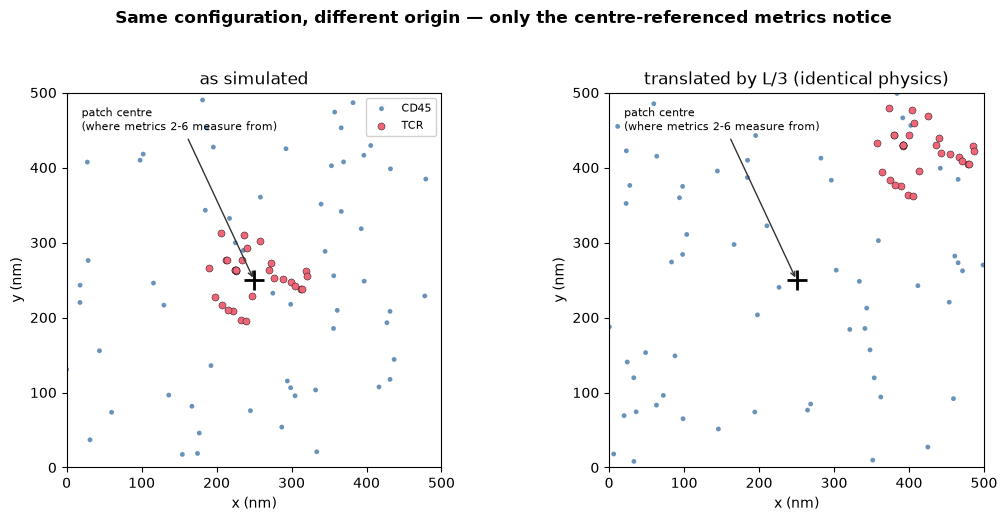

In [3]:
from ks_tutorial import COLOR_CD45 as CC, COLOR_TCR as CT

# One run, then read the final configuration out of the frame dump.
with tempfile.TemporaryDirectory() as rd:
    run_ks(rd, dump_frames=True, dump_interval=BASE["n_steps"],
           monitor_binding=3.0, **BASE)
    meta = json.loads((Path(rd) / "frames" / "meta.json").read_text())
    n_t, n_c, L = meta["n_tcr"], meta["n_cd45"], meta["patch_nm"]
    mol = np.fromfile(Path(rd) / "frames" / f"mol_{meta['n_steps'] // meta['dump_interval']:05d}.bin",
                      dtype=np.float64)
tcr0, cd450 = mol[: n_t * 2].reshape(n_t, 2), mol[n_t * 2:].reshape(n_c, 2)


def c_median(x):
    """The order statistic the C code uses (see KS 3)."""
    return float(np.sort(x)[len(x) // 2])


def centre_metrics(tcr, cd45):
    """Metric family 2-6: everything is measured from the patch centre."""
    ctr = L / 2
    rt, rc = np.hypot(*(tcr - ctr).T), np.hypot(*(cd45 - ctr).T)
    width = max(0.0, c_median(rc) - c_median(rt))
    bins = np.linspace(0, L * 0.7072, 101)
    ht, _ = np.histogram(rt, bins=bins, density=True)
    hc, _ = np.histogram(rc, bins=bins, density=True)
    overlap = float(np.minimum(ht, hc).sum() * (bins[1] - bins[0]))
    return width, overlap


def nn_p10(a, b):
    """Metric family 7-8: nearest-neighbour distances, minimum-image. Never
    mentions the patch centre, so translation cannot change it."""
    d = a[:, None, :] - b[None, :, :]
    d -= L * np.round(d / L)
    r = np.hypot(d[..., 0], d[..., 1]).min(axis=1)
    return float(np.sort(r)[max(len(r) // 10, 0)])


# Slide everything by a third of the box, wrapping periodically.
SHIFT = L / 3.0
tcr1, cd451 = (tcr0 + SHIFT) % L, (cd450 + SHIFT) % L

rows = []
for label, tt, cc in (("as simulated", tcr0, cd450), ("translated by L/3", tcr1, cd451)):
    w, ov = centre_metrics(tt, cc)
    rows.append((label, w, ov, nn_p10(tt, cc), nn_p10(cc, tt)))

print(f"{'configuration':<20}{'width (nm)':>12}{'overlap':>10}"
      f"{'TCR->CD45 P10':>16}{'CD45->TCR P10':>16}")
for label, w, ov, a, b in rows:
    print(f"{label:<20}{w:12.2f}{ov:10.3f}{a:16.2f}{b:16.2f}")
print()
print(f"centre-referenced width changed by {abs(rows[0][1] - rows[1][1]):.1f} nm; "
      f"nearest-neighbour P10 changed by {abs(rows[0][3] - rows[1][3]):.2e} nm")

fig, ax = plt.subplots(1, 2, figsize=(11, 5.2))
for a, (label, tt, cc) in zip(ax, (("as simulated", tcr0, cd450),
                                   ("translated by L/3 (identical physics)", tcr1, cd451))):
    a.scatter(*cc.T, s=12, color=CC, alpha=.8, edgecolors="none", label="CD45")
    a.scatter(*tt.T, s=26, color=CT, edgecolors="k", linewidths=.3, label="TCR")
    a.plot(L / 2, L / 2, "+", color="#000", ms=14, mew=2)
    a.annotate("patch centre\n(where metrics 2-6 measure from)", xy=(L / 2, L / 2),
               xytext=(0.04 * L, 0.90 * L), fontsize=8,
               arrowprops=dict(arrowstyle="->", color="#333"))
    a.set_xlim(0, L); a.set_ylim(0, L); a.set_aspect("equal")
    a.set_xlabel("x (nm)"); a.set_ylabel("y (nm)"); a.set_title(label)
ax[0].legend(loc="upper right", fontsize=8, framealpha=.9)
fig.suptitle("Same configuration, different origin — only the centre-referenced "
             "metrics notice", fontsize=12, weight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()

### What just happened

Nothing physical changed. The molecules kept their neighbours, their separations, and
their energies; only the labelling of the origin moved. Yet:

- **`depletion_width_nm` and `overlap` moved a lot.** They ask "how far is each species
  from the patch centre?", and the contact is no longer near it. They are reporting the
  contact's *position*, not its *segregation*.
- **The two nearest-neighbour P10 metrics are unchanged to floating-point noise.** They
  ask "how close is the nearest CD45 to each TCR?", which no choice of origin can affect.

Real contacts are not obliged to form in the middle of your patch. They form where the
ligands are, they wander, and with several ligand clusters you can get more than one.
Whenever that is a possibility, metrics 2-6 are measuring the wrong thing, and they will
do it quietly — returning a confident number the whole time.

This is the same failure you already met in KS 3, where `pmhc_mode=uniform` gave
`depletion_width_nm = 0.000` on every seed. Not because segregation was absent, but
because it was not arranged around the patch centre.

### Trap 1 — `null` is not `0`

The two geometry-free metrics arrive as JSON `null` unless `--monitor-binding` is set.
Loaded into a dataframe they become `NaN`; summed or averaged carelessly they become
`0`; plotted, they vanish without comment.

If you are building a sweep over these metrics — which is exactly what
`experiments/ks_behavior_sweep/` does — set `--monitor-binding` in your fixed arguments
or you will collect two columns of nothing. Note that the flag takes a **distance
threshold in nm**, not a boolean: `--monitor-binding 3.0` means "a TCR counts as bound
within 3 nm of a pMHC".

### Trap 2 — a typo silently selects the other mode

`--binding_mode`, `--step_mode` and `--pmhc_mode` are parsed as
`match(expected) ? A : B` with **no validation**. Anything that is not an exact match
for the first option becomes the second one. A misspelling does not error; it runs a
different model.

In [4]:
w_gauss = run_ks(**{**BASE, "binding_mode": "gaussian"})["depletion_width_nm"]
w_force = run_ks(**{**BASE, "binding_mode": "forced"})["depletion_width_nm"]
w_typo = run_ks(**{**BASE, "binding_mode": "gausian"})["depletion_width_nm"]   # typo!

print(f"  binding_mode=gaussian    -> {w_gauss:.4f}")
print(f"  binding_mode=forced      -> {w_force:.4f}")
print(f"  binding_mode='gausian'   -> {w_typo:.4f}   <-- the typo")
print()
same_as = "forced" if abs(w_typo - w_force) < 1e-9 else "gaussian"
print(f"The misspelling silently ran: {same_as}")
print("No warning, no error, no clue in the output JSON.")

  binding_mode=gaussian    -> 147.7039
  binding_mode=forced      -> 154.7740
  binding_mode='gausian'   -> 154.7740   <-- the typo

The misspelling silently ran: forced
No warning, no error, no clue in the output JSON.


### Trap 3 — a `--params` file overrides an explicit command-line flag

The usual precedence is *CLI beats file beats default*. For the three mode flags that
is **inverted**: `load_params_file` applies `pmhc_mode`, `binding_mode` and `step_mode`
unconditionally, with no check for whether you also passed them on the command line.

So a stale params file silently wins over the flag you are staring at in your shell
history.

In [5]:
with tempfile.TemporaryDirectory() as d:
    pf = os.path.join(d, "params.json")
    json.dump({"binding_mode": "forced"}, open(pf, "w"))
    w_conflict = run_ks(**{**BASE, "binding_mode": "gaussian", "params": pf})["depletion_width_nm"]

winner = "the FILE" if abs(w_conflict - w_force) < 1e-9 else "the CLI flag"
print(f"  CLI says --binding_mode gaussian, params.json says forced")
print(f"  result = {w_conflict:.4f}  ->  {winner} won")
print()
print("  (numeric options such as --seed use a sentinel comparison instead, so passing")
print("   the default value explicitly is indistinguishable from not passing it at all)")

  CLI says --binding_mode gaussian, params.json says forced
  result = 154.7740  ->  the FILE won

  (numeric options such as --seed use a sentinel comparison instead, so passing
   the default value explicitly is indistinguishable from not passing it at all)


### Trap 4 — `--dump-frames` switches off your instrumentation

The output branch in `main.cpp` is an `if / else if / else` chain: the frame-dumping
path never evaluates the binding monitor or the snapshot sampler. You cannot get a movie
and a metric time series from the same run — and nothing tells you which one you lost.

In [6]:
no_frames = run_ks(**{**BASE, "monitor_binding": 3.0, "monitor_interval": 50})
with tempfile.TemporaryDirectory() as d:
    frames = run_ks(d, dump_frames=True, dump_interval=BASE["n_steps"],
                    **{**BASE, "monitor_binding": 3.0, "monitor_interval": 50})

print(f"  without --dump-frames : binding_timeseries has "
      f"{len(no_frames.get('binding_timeseries', []))} samples")
print(f"  with    --dump-frames : binding_timeseries has "
      f"{len(frames.get('binding_timeseries', []))} samples")
print("\n  Same flags, same request -- the time series is simply gone.")

  without --dump-frames : binding_timeseries has 9 samples
  with    --dump-frames : binding_timeseries has 0 samples

  Same flags, same request -- the time series is simply gone.


### Trap 5 — seven flags exist only on the binary

`python -m models.kinetic_segregation` is a thin wrapper, and its `argparse` does not
expose everything the C CLI accepts. These seven are **unreachable through the wrapper**:

`--u_assoc`, `--sigma_bind`, `--sigma_r`, `--patch_size`, `--monitor-binding`,
`--monitor-interval`, `--snapshot-interval`

That list includes `--patch_size`, which KS 3 showed is half of the resolution
constraint, and all three instrumentation flags. It is why
`experiments/ks_behavior_sweep/run.py` calls `ks_gpu` directly rather than going through
the wrapper — and why `ks_tutorial.run_ks` does the same.

If you drive the model through a framework `ModelSpec` (whose adapter invokes the
wrapper), you cannot set any of them.

## Choosing a metric: a short decision guide

| Situation | Use | Avoid |
|---|---|---|
| Contact is centred and roughly circular | 2–6, whichever suits | — |
| Contact is off-centre, irregular, or multi-focal | 7–8 (set `--monitor-binding`) | 2–6, which are all centre-referenced |
| You need to detect *inversion* (CD45 inside TCR) | 5 — the only one that can go negative | 2, which clamps at 0 |
| Comparing runs whose initial conditions differ | a normalised quantity (see KS 4) | any raw metric — it may be saturated by seeding |
| Watching a run evolve | `--snapshot-interval` | a single final value |

And a habit worth forming: **whenever a metric reports no effect, verify it can respond
to something before believing it.** In KS 4 that check was what separated "the model
ignores binding energy" from "our ruler was saturated".

## Scientific checkpoint

1. You sweep 200 parameter combinations and collect all eight metrics. Columns 7 and 8
   are entirely empty. What single flag did you forget, and why did nothing warn you?
2. Your contact zone forms off-centre. Which metrics are still trustworthy?
3. `depletion_percentile_gap_nm` comes back negative. Is that a bug?

<details>
<summary>Check yourself</summary>

1. `--monitor-binding <nm>`. Without it `find_bound_tcrs` short-circuits, the bound set
   is empty, and both metrics are undefined — emitted as JSON `null`, which is a valid
   value rather than an error.
2. Only 7 and 8, and only if you set `--monitor-binding`. Everything else measures
   distance from the patch centre, which is no longer where the contact is.
3. No — it is the one metric permitted to go negative, and it is telling you something
   real: the inner quartile of CD45 sits closer to the centre than the outer quartile of
   TCR. Either segregation has inverted or the contact has dissolved. `depletion_width_nm`
   would have hidden this behind its `max(0, ...)` clamp.
</details>

## Where to go next

You have finished the KS series. From here:
- `notebooks/01_explore_models.ipynb` onward — the metamodel track, where KS becomes one
  of four coupled partial models.
- `experiments/ks_behavior_sweep/` — a production sweep over κ and dt, collecting all
  eight metrics with `--monitor-binding` correctly set.

In [7]:
# Final check: every trap in this notebook, asserted.
assert get(plain, "depletion_bound_tcr_cd45_nn_p10_nm") is None, "trap 1 no longer reproduces"
assert get(with_monitor, "depletion_bound_tcr_cd45_nn_p10_nm") is not None
assert abs(w_typo - w_force) < 1e-9, "trap 2: typo should silently select the other mode"
assert abs(w_typo - w_gauss) > 1e-9
assert abs(w_conflict - w_force) < 1e-9, "trap 3: params file should override the CLI flag"
assert len(no_frames.get("binding_timeseries", [])) > 0
assert len(frames.get("binding_timeseries", [])) == 0, "trap 4: dump-frames should kill the monitor"
print("[KS_5 self-check OK]")

[KS_5 self-check OK]
